In [1]:
import sys, os
path = os.path.abspath('../src')
sys.path.insert(0, path)

In [4]:
from shapely.geometry import box
import geopandas as gpd

In [29]:
geo = box(-10, 35, 10, 45)
gdf = gpd.GeoDataFrame({'id':[1], 'geometry':[geo]}, crs='EPSG:4326')

geo2 = box(-15, 33, 8, 42)
gdf2 = gpd.GeoDataFrame({'id':[2], 'geometry':[geo2]}, crs='EPSG:4326')


<Axes: >

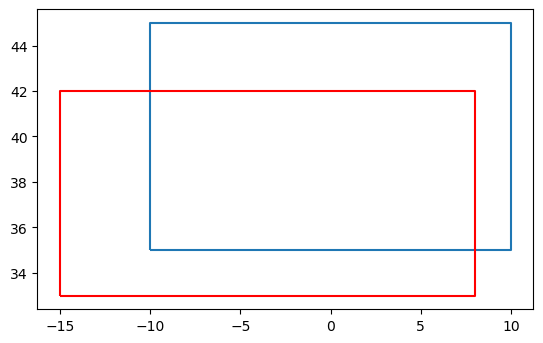

In [30]:
ax = gdf.boundary.plot()
gdf2.boundary.plot(ax=ax, color='red')

<Axes: >

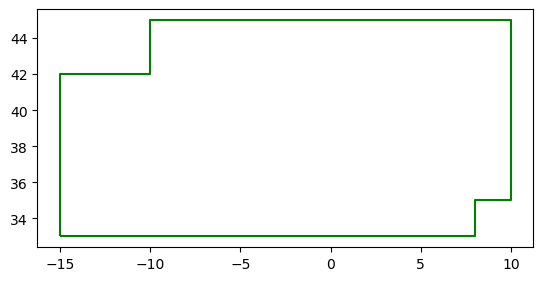

In [33]:
udf = gpd.overlay(gdf, gdf2, how='union').union_all()
udf = gpd.GeoDataFrame(geometry=[udf])
udf.boundary.plot(color='green')

In [45]:
udf.geometry.iloc[0].geom_type

'Polygon'

In [61]:
adf = gpd.overlay(gdf, gdf2, how='symmetric_difference').union_all()
adf = gpd.GeoDataFrame(geometry=[adf])
# adf.boundary.plot(color='green')
adf.geometry.iloc[0].is_empty

False

In [66]:
adf.geometry.geom_type == 'MultiPolygon'

0    True
dtype: bool